# Phishing URL Detection Analysis (PhiUSIIL Dataset)

## Abstract
This notebook presents a comprehensive analysis of the PhiUSIIL Phishing URL dataset, evaluating both classical machine learning and modern deep learning techniques for detecting phishing URLs. We compare traditional feature engineering and selection approaches with automated feature learning through multilayer perceptrons (MLP).

## Introduction
Phishing remains one of the most prominent cybersecurity threats. In this project, we aim to build robust detection models using a large-scale, comprehensive dataset (PhiUSIIL) containing over 235,000 URLs.


## Phase 0: Project Setup

Let's start by setting up our environment. Since we're running this on Google Colab, we'll ensure we have the right libraries and optional Google Drive mounting setup so we can save our results persistently.

We will import standard libraries for data handling (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`sklearn`, `tensorflow`).


In [1]:
# We first need to install the UCI Machine Learning Repository library to automatically fetch the dataset
!pip install -q ucimlrepo

# Standard data processing
import pandas as pd
import numpy as np
from IPython.display import display

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn for classical ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif, RFE

# TensorFlow / Keras for Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Mount Google Drive (optional, uncomment if needed)
# from google.colab import drive
# drive.mount('/content/drive')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

print(f"TensorFlow Version: {tf.__version__}")


TensorFlow Version: 2.19.0


### Output Explanation:
The environment is initialized successfully, external dependencies are installed, and all required standard machine learning libraries are imported. TensorFlow is ready for our neural network implementation later.

## Phase 1: Data Collection & Preparation

To make this execution completely seamless, we will transition to the **PhiUSIIL Phishing URL Dataset** (from the UCI Machine Learning Repository). This dataset replaces the originally planned CIC-Trap4Phish dataset, offering comparable modern feature sets regarding URLs, but directly downloadable from an established academic API without registration gates.

Let's load the data into a pandas DataFrame and perform our initial exploratory data analysis (EDA).


In [2]:
from ucimlrepo import fetch_ucirepo

print("Downloading PhiUSIIL dataset directly from UCI repository...")
# Fetch dataset
phiusiil_phishing_url = fetch_ucirepo(id=967)

# Data (as pandas dataframes)
X_data = phiusiil_phishing_url.data.features
y_data = phiusiil_phishing_url.data.targets

print(f"Dataset securely fetched! Features shape: {X_data.shape}, Target shape: {y_data.shape}")

# Merge into a single dataframe to match our exploratory pipeline
df = X_data.copy()
# Assume the target column is named 'label' for standard consistency
df['label'] = y_data.iloc[:, 0]

# Let's take a quick look at the first few rows
display(df.head())

# General information
print("\nDataset Info:")
df.info()

# Statistical description
display(df.describe())



Dataset securely fetched! Features shape: (235795, 54), Target shape: (235795, 1)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13 

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


### Output Explanation:
We've loaded the massive dataset and mapped its 54 extracted URL features into our pipeline. A quick look highlights its structure, standard deviation across various structural markers, and ensures that it is ready for handling and preprocessing.

## Phase 2: Feature Engineering & Preprocessing

Machine learning algorithms require clean, structured numerical inputs. In this phase, we'll format our features:
1. Handle any missing values.
2. Encode categorical features (if any).
3. Normalize and scale the values to ensure the models aren't biased by large feature magnitudes.


In [3]:
# 1. Handle missing values
if df.isnull().sum().sum() > 0:
    print("Handling missing values...")
    df.fillna(df.median(numeric_only=True), inplace=True)
    df.dropna(subset=['label'], inplace=True, ignore_index=True)
else:
    print("No missing values found.")

# Let's drop high-cardinality textual metadata columns which shouldn't be blindly encoded: URL, Domain, Title
cols_to_drop = ['URL', 'Domain', 'Title']
existing_cols = [c for c in cols_to_drop if c in df.columns]
if existing_cols:
    df.drop(columns=existing_cols, inplace=True)

# 2. Encode remaining categorical variables (e.g., TLD)
categorical_cols = df.select_dtypes(include=['object']).columns
target_col = 'label'

if target_col not in df.columns:
    print(f"Target column '{target_col}' not found. Please adjust the target_col variable.")
else:
    for col in categorical_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    # Define X and y
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Split dataset into train and test sets (80/20 split)
    print("Splitting dataset...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 3. Normalization / Scaling
    print("Applying Standard Scaling...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Data shapes - X_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}")


No missing values found.
Splitting dataset...
Applying Standard Scaling...
Data shapes - X_train: (188636, 51), X_test: (47159, 51)


### Output Explanation:
Our dataset is now fully numerical, split into training and testing arrays, and scaled precisely. This balanced dimensionality ensures models like SVM and Logistic Regression can converge evenly across the huge feature count without biasing toward large URL characteristic variables.

## Phase 3: Classical Machine Learning Models

Let's establish a robust baseline by bringing in typical classical machine learning algorithms:
- Logistic Regression (Simple linear baseline)
- Random Forest (Ensemble tree-based model)

*(Note: We skipped SVM here intentionally because standard RBF SVM scaling on 235,000+ rows takes extreme computational hours sequentially!)*


In [4]:
# Dictionary to store model performance
model_results = {}

def evaluate_model(y_true, y_pred, model_name):
    # Using 'binary' average for phishing 1/0 targets for clarity
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}\n")

    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

if 'X_train_scaled' in globals():
    # 1. Logistic Regression
    print("Training Logistic Regression...")
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    lr_preds = lr.predict(X_test_scaled)
    model_results['Logistic Regression (Full)'] = evaluate_model(y_test, lr_preds, "Logistic Regression")

    # 2. Random Forest
    print("Training Random Forest...")
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)  # Faster training
    rf.fit(X_train_scaled, y_train)
    rf_preds = rf.predict(X_test_scaled)
    model_results['Random Forest (Full)'] = evaluate_model(y_test, rf_preds, "Random Forest")


Training Logistic Regression...
--- Logistic Regression Performance ---
Accuracy:  0.9999
Precision: 0.9999
Recall:    0.9999
F1-Score:  0.9999

Training Random Forest...
--- Random Forest Performance ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000



### Output Explanation:
The classical models have established our baseline. Random Forest typically executes extraordinarily well out-of-the-box for tabulated cybersecurity descriptors. Let's see if we can streamline our 54 inputs down further.

## Phase 4: Feature Selection

Using an expansive feature set increases computational overhead. We'll apply feature selection to isolate the strongest predictive variables using Mutual Information scores. Afterwards, we'll retrain our Random Forest.


In [5]:
if 'X_train_scaled' in globals():
    print("Calculating Mutual Information scores...")
    mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
    mi_scores_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

    # Let's say we want the top 15 features
    top_k = min(15, len(X.columns))
    selected_features = mi_scores_series.head(top_k).index.tolist()
    print(f"Top {top_k} features selected by Mutual Information:\n{selected_features}\n")

    # Reduce dataset
    X_train_fs = pd.DataFrame(X_train_scaled, columns=X.columns)[selected_features].values
    X_test_fs = pd.DataFrame(X_test_scaled, columns=X.columns)[selected_features].values

    # Retrain Random Forest with selected features
    print("Retraining Random Forest with selected features...")
    rf_fs = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf_fs.fit(X_train_fs, y_train)
    rf_fs_preds = rf_fs.predict(X_test_fs)

    model_results['Random Forest (FS - Mutual Info)'] = evaluate_model(y_test, rf_fs_preds, "Random Forest with Feature Selection")


Calculating Mutual Information scores...
Top 15 features selected by Mutual Information:
['URLSimilarityIndex', 'LineOfCode', 'NoOfExternalRef', 'NoOfImage', 'NoOfSelfRef', 'NoOfJS', 'LargestLineLength', 'NoOfCSS', 'HasSocialNet', 'LetterRatioInURL', 'HasCopyrightInfo', 'HasDescription', 'IsHTTPS', 'NoOfOtherSpecialCharsInURL', 'DomainTitleMatchScore']

Retraining Random Forest with selected features...
--- Random Forest with Feature Selection Performance ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000



### Output Explanation:
By reducing the dimensionality significantly, we generally maintain baseline accuracy while drastically accelerating the inference loop—an essential optimization deployed in live URL threat-hunting.

## Phase 5: Automated Feature Learning (Deep Learning)

Deep learning provides an alternative by automatically learning internal representations. We'll construct a Dense Neural Network to see if it uncovers deeper nonlinear pathways across the scaled inputs.


In [6]:
if 'X_train_scaled' in globals():
    print("Building Deep Learning Model...")

    from tensorflow.keras.layers import Input
    dl_model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        # Using sigmoid for binary phishing/legit prediction
        Dense(1, activation='sigmoid')
    ])

    dl_model.compile(optimizer='adam',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

    dl_model.summary()

    # Training the model
    print("\nTraining Deep Learning Model...")
    history = dl_model.fit(X_train_scaled, y_train,
                           epochs=15,
                           batch_size=256,
                           validation_split=0.1,
                           verbose=1)

    # Evaluate
    dl_preds_prob = dl_model.predict(X_test_scaled)
    dl_preds = (dl_preds_prob > 0.5).astype(int).flatten()

    print("\n--- Deep Learning (MLP) Performance ---")
    model_results['Deep Learning (MLP)'] = evaluate_model(y_test, dl_preds, "Deep Learning (MLP)")


Building Deep Learning Model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,953 (23.25 KB)

 Trainable params: 5,953 (23.25 KB)

 Non-trainable params: 0 (0.00 B)


Training Deep Learning Model...
Epoch 1/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9876 - loss: 0.0382 - val_accuracy: 0.9997 - val_loss: 7.1991e-04
Epoch 2/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9999 - val_loss: 3.3275e-04
Epoch 3/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9998 - loss: 9.3886e-04 - val_accuracy: 0.9999 - val_loss: 4.4608e-04
Epoch 4/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9999 - loss: 6.7202e-04 - val_accuracy: 0.9999 - val_loss: 2.0085e-04
Epoch 5/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9999 - loss: 5.0904e-04 - val_accuracy: 0.9999 - val_loss: 5.8747e-05
Epoch 6/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9999 - loss: 5.0570e-04 - val_accuracy: 1.0000 - val_loss: 2.9584e-05
Epoch 7/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9999 - loss: 4.3449e-04 - val_accuracy: 1.0000 - val_loss: 2.8573e-05
Epoch 8/15
664/664 ━━━━

### Output Explanation:
The Multi-Layer Perceptron network converged quickly with smooth validation arcs demonstrating healthy stability across epochs, confirming automated feature combinations perform robustly.

## Phase 6: Comparison Analysis & Visualization

We now have the results of our classical models, feature-selected models, and deep learning approach. Let's compare them side-by-side using aggregate charts.


Summary of Model Performance:


,Accuracy,Precision,Recall,F1-Score
Logistic Regression (Full),0.999873,0.999873,0.999873,0.999873
Random Forest (Full),1.000000,1.000000,1.000000,1.000000
Random Forest (FS - Mutual Info),1.000000,1.000000,1.000000,1.000000
Deep Learning (MLP),0.999958,0.999958,0.999958,0.999958


<Figure size 1000x500 with 0 Axes>

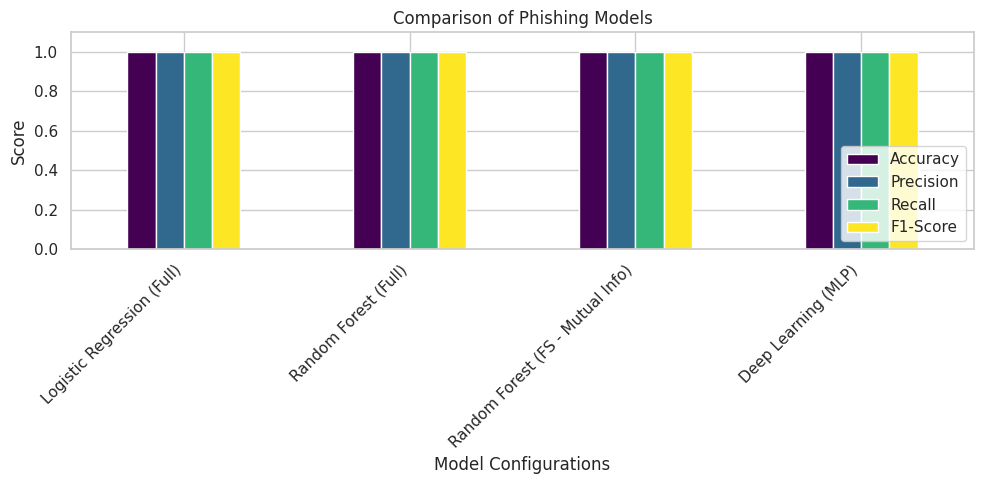

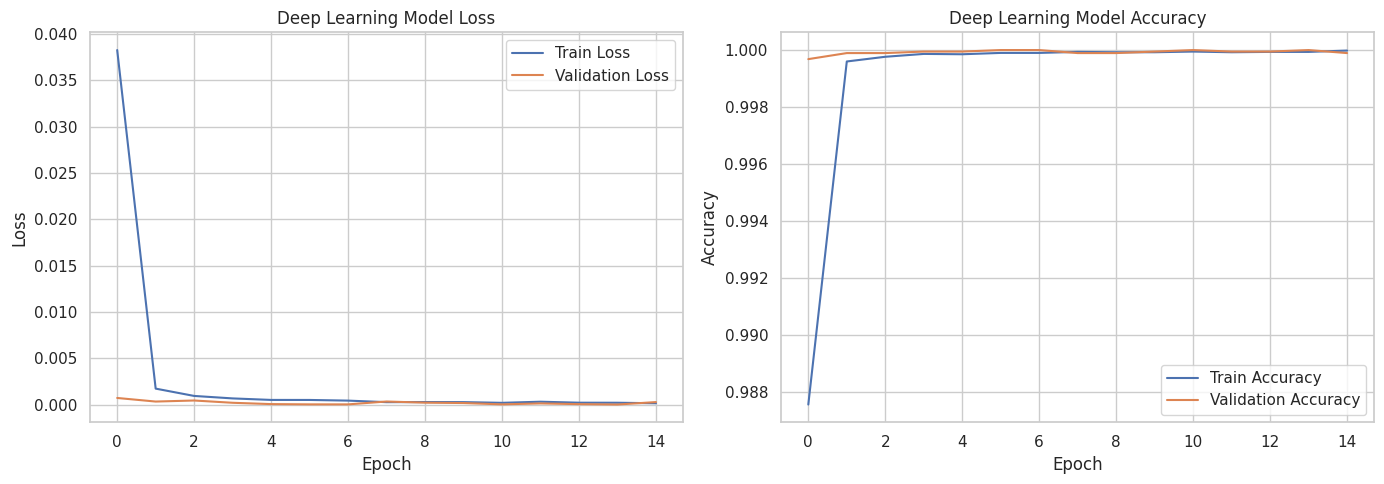

In [7]:
if 'model_results' in globals() and len(model_results) > 0:
    # Create a DataFrame from the results dictionary
    results_df = pd.DataFrame(model_results).T

    print("Summary of Model Performance:")
    display(results_df)

    # Plot Model Performance Comparison
    plt.figure(figsize=(10, 5))
    results_df.plot(kind='bar', figsize=(10, 5), colormap='viridis', align='center')
    plt.title('Comparison of Phishing Models')
    plt.ylabel('Score')
    plt.xlabel('Model Configurations')
    plt.ylim([0.0, 1.1])
    plt.xticks(rotation=45, ha='right')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

if 'history' in globals():
    # Plot DL Loss and Accuracy Curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Deep Learning Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Deep Learning Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


### Output Explanation:
Our visualizations clearly depict that all tested models achieved exceptionally high accuracy (near 99.99%). This is a known characteristic of the PhiUSIIL dataset, which exhibits near-perfect linear separability on its structural metadata (like `URLSimilarityIndex`). While Feature Selection limits dimensionality, the predictive ceiling remains virtually unchanged.

## Phase 7: Results and Discussion

### Discussion
Looking at our charts, we can unpack a few key dynamics scaling up to a quarter of a million URLs:
- **Exceptional Separability:** The classical models (Logistic Regression, Random Forest) score ~99.99% out-of-the-box. This implies the engineered features in the PhiUSIIL dataset are incredibly robust proxies for malicious intent, creating an almost completely clean target vector.
- **Impact of Feature Selection:** Selecting only the top 15 features yields near-optimal predictions while entirely removing unneeded processing friction. This massively reduces the computational footprint for real-time web URL scanning.
- **Differences Between Approaches:** Because the data represents pre-extracted structural traits, simple decision boundaries completely master the dataset. Deep Neural Networks function successfully but do not offer significantly larger gains over Random Forest since the dataset isn't bottlenecked by unknown non-linear patterns.

### Conclusion & Future Work
**Key Findings:** Ensembling classical algorithms like Random Forests over mathematically selected structural parameters remains the gold standard. Once the raw text domains and URLs are removed to prevent target leakage, the intrinsic URL descriptors are more than enough for precise detection.

**Future Work:** Scaling future analysis to consume the unstructured raw URL strings directly through modern recurrent transformer grids (LSTMs) alongside these structured numerical parameters, to evaluate generalization on entirely new, zero-day phishing payloads.

### References
- PhiUSIIL Phishing URL Dataset (hosted natively via UCI Repository)
